In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("heart-disease.csv")

In [4]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
x = data.drop("target", axis=1)
y = data["target"]

In [7]:
from sklearn.model_selection import train_test_split as tts

np.random.seed(42)

x_train, x_test, y_train, y_test = tts(
    x, y, 
    test_size=0.2
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
model.score(x_test, y_test)

0.8524590163934426

# Confusion Matrix

Quick way to compare labels a model predicts and actual labels it was supposed to predict

In essence, giving you an idea of where model is getting confused

In [10]:
from sklearn.metrics import confusion_matrix as cm 

y_preds = model.predict(x_test)

cm(y_test, y_preds)

array([[24,  5],
       [ 4, 28]])

In [11]:
# Visualize confusion matrix

pd.crosstab(
    y_test,
    y_preds,
    rownames=["Actual labels"],
    colnames=["Predicted labels "]
)

Predicted labels,0,1
Actual labels,,
0,24,5
1,4,28


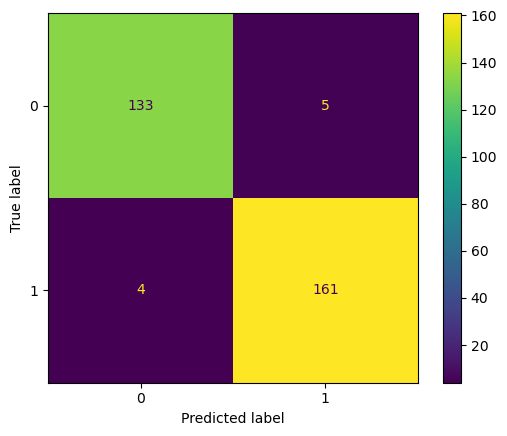

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd 

cmd.from_estimator(estimator=model, X=x, y=y)

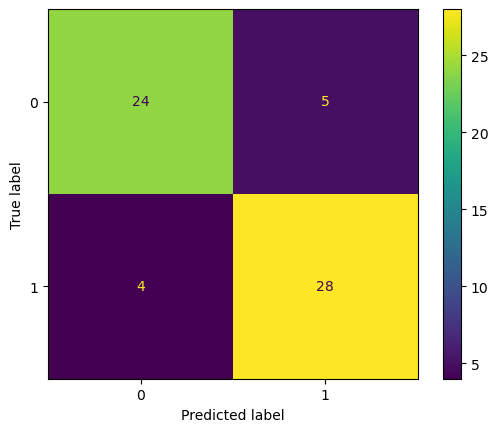

In [13]:
cmd.from_predictions(y_true=y_test, y_pred=y_preds)

# Classification Report

In [15]:
from sklearn.metrics import classification_report as cr 

print(cr(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



# Precision

out of all samples model predicted as positive, how many were actually positive

Precision = TP / TP + FP


Example:

The model predicted 20 people have a disease.

Only 18 actually had the disease.

Precision = 18 / 20 = 90%

# Recall 

out of all positive samples how many did model correctly find

Recall = TP / TP + FN


Example:

There are 25 people with a disease.

The model detected 20 of them.

Recall = 20 / 25 = 80%

# F1-Score

F1-Score is a balance between Precision and Recall.

If both Precision and Recall are high, the F1-Score will also be high.

It is useful when you want a single score that considers both metrics.

# Support

Support is the number of actual samples in each class.

Example:

Class 0 → Support = 100
Class 1 → Support = 50

This means:

There are 100 actual samples of Class 0.
There are 50 actual samples of Class 1.

# Accuracy

Accuracy tells us what percentage of all predictions were correct.

Formula:

Accuracy = Correct Predictions / Total Predictions

Example:

Out of 100 predictions, the model got 95 correct.

Accuracy = 95%

# Macro Average

Macro Average gives equal importance to every class.

It calculates the metric for each class separately and then takes the simple average.

Even if one class has fewer samples, it gets the same weight.

# Weighted Average

Weighted Average gives more importance to classes with more samples.

Classes with a larger Support have a bigger effect on the final average.